# 05 — Results Analysis

**Central question**: Does cross-asset OFI (Nifty → Bank Nifty / large-caps) add predictive power
beyond each asset's own OFI?

This notebook produces:
1. Incremental R² test (full vs own-only)
2. Signal decay analysis across horizons
3. Final summary table for the research narrative

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import TARGET_ASSETS, SIGNAL_ASSET, OFI_HORIZONS, DEFAULT_FWD_HORIZON
from src.data_loader import load_processed
from src.features import prepare_dataset
from src.evaluation import (
    run_walk_forward, incremental_r2, summarise_results, signal_decay_analysis
)

sns.set_style('whitegrid')
%matplotlib inline

## 5.1 Load walk-forward results

In [2]:
results_df = pd.read_csv('../outputs/tables/walk_forward_results.csv')
print(f"Loaded {len(results_df)} fold results.")
results_df.head()

Loaded 168 fold results.


,fold,train_start,train_end,test_start,test_end,n_train,n_test,ic,r2,target,feature_set,model
0,0,2024-01-02 09:15:00,2024-06-28 15:29:00,2024-07-01 09:15:00,2024-07-31 15:29:00,48375,8625,-0.038441,-0.003290,BANKNIFTY,own,ols
1,1,2024-02-01 09:15:00,2024-07-31 15:29:00,2024-08-01 09:15:00,2024-08-30 15:29:00,48750,8250,0.050187,0.001055,BANKNIFTY,own,ols
2,2,2024-03-01 09:15:00,2024-08-30 15:29:00,2024-09-02 09:15:00,2024-09-30 15:29:00,49125,7875,-0.030548,-0.001196,BANKNIFTY,own,ols
3,3,2024-04-01 09:15:00,2024-09-30 15:29:00,2024-10-01 09:15:00,2024-10-31 15:29:00,49125,8625,0.012550,0.000043,BANKNIFTY,own,ols
4,4,2024-05-01 09:15:00,2024-10-31 15:29:00,2024-11-01 09:15:00,2024-11-29 15:29:00,49500,7875,-0.010158,-0.000734,BANKNIFTY,own,ols


## 5.2 Incremental R² — Does cross-asset OFI add value?

In [3]:
incr_rows = []

for target in TARGET_ASSETS:
    for mn in ['ols', 'ridge', 'xgboost']:
        full_mask = (results_df['target'] == target) & (results_df['model'] == mn) & (results_df['feature_set'] == 'full')
        own_mask  = (results_df['target'] == target) & (results_df['model'] == mn) & (results_df['feature_set'] == 'own')

        res_full = results_df[full_mask].reset_index(drop=True)
        res_own  = results_df[own_mask].reset_index(drop=True)

        if len(res_full) == 0 or len(res_own) == 0:
            continue

        incr = incremental_r2(res_full, res_own)
        incr_rows.append({
            'target': target,
            'model': mn,
            'mean_delta_r2': incr['delta_r2'].mean(),
            'std_delta_r2': incr['delta_r2'].std(),
            'mean_delta_ic': incr['delta_ic'].mean(),
            'n_folds': len(incr),
            'pct_positive': (incr['delta_r2'] > 0).mean() * 100,
        })

incr_table = pd.DataFrame(incr_rows)
print("Incremental R² from Cross-Asset OFI (full - own)")
print("=" * 80)
print(incr_table.round(6).to_string(index=False))

incr_table.to_csv('../outputs/tables/incremental_r2.csv', index=False)

Incremental R² from Cross-Asset OFI (full - own)
   target   model  mean_delta_r2  std_delta_r2  mean_delta_ic  n_folds  pct_positive
BANKNIFTY     ols      -0.000120      0.001374       0.000996        7     57.142857
BANKNIFTY   ridge      -0.000080      0.001107       0.001638        7     57.142857
BANKNIFTY xgboost      -0.002494      0.005586      -0.013273        7     28.571429
 HDFCBANK     ols      -0.000591      0.001707       0.001313        7     57.142857
 HDFCBANK   ridge      -0.000519      0.001584       0.002006        7     57.142857
 HDFCBANK xgboost      -0.000916      0.003272      -0.002696        7     42.857143
 RELIANCE     ols      -0.000358      0.000915       0.004672        7     28.571429
 RELIANCE   ridge      -0.000369      0.000801       0.004359        7     28.571429
 RELIANCE xgboost      -0.000950      0.003028      -0.009183        7     42.857143
     INFY     ols      -0.000732      0.000630      -0.007691        7     14.285714
     INFY   ridg

## 5.3 Signal decay across OFI horizons

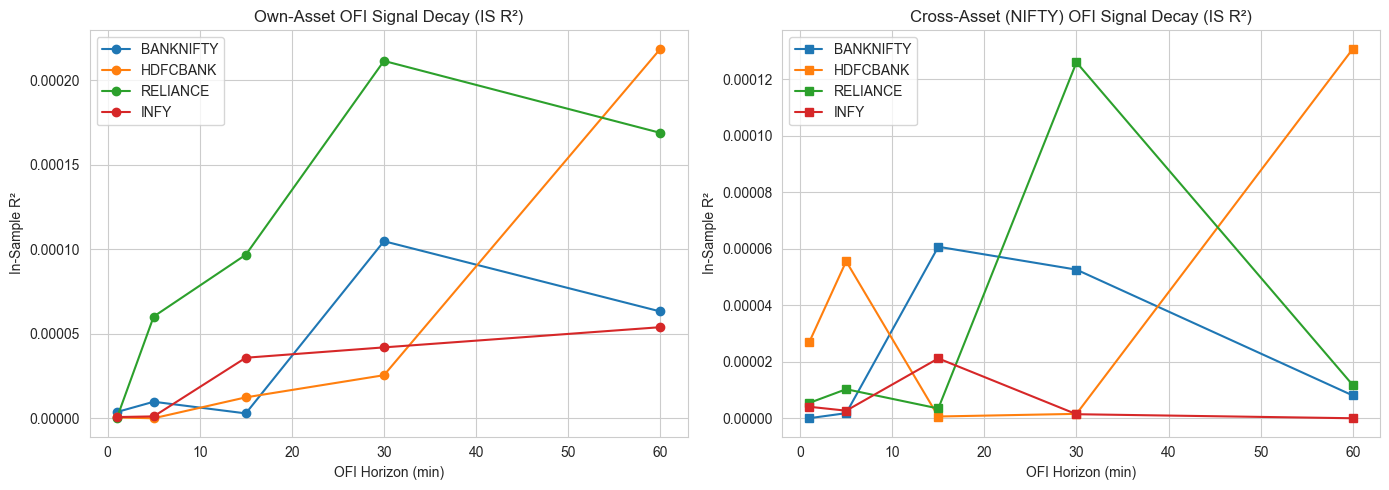

In [4]:
panel = load_processed('panel')
ofi_df = load_processed('ofi_all')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for target in TARGET_ASSETS:
    close = panel[target]['close']
    _, y = prepare_dataset(ofi_df, close, target, feature_set='own')

    # Own-asset decay
    decay = signal_decay_analysis(ofi_df, y, target, OFI_HORIZONS)
    axes[0].plot(decay['horizon'], decay['is_r2'], marker='o', label=target)

    # Cross-asset (NIFTY) decay for this target
    decay_cross = signal_decay_analysis(ofi_df, y, SIGNAL_ASSET, OFI_HORIZONS)
    axes[1].plot(decay_cross['horizon'], decay_cross['is_r2'], marker='s', label=target)

axes[0].set_title('Own-Asset OFI Signal Decay (IS R²)')
axes[0].set_xlabel('OFI Horizon (min)')
axes[0].set_ylabel('In-Sample R²')
axes[0].legend()

axes[1].set_title(f'Cross-Asset ({SIGNAL_ASSET}) OFI Signal Decay (IS R²)')
axes[1].set_xlabel('OFI Horizon (min)')
axes[1].set_ylabel('In-Sample R²')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/signal_decay.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.4 Model comparison bar chart

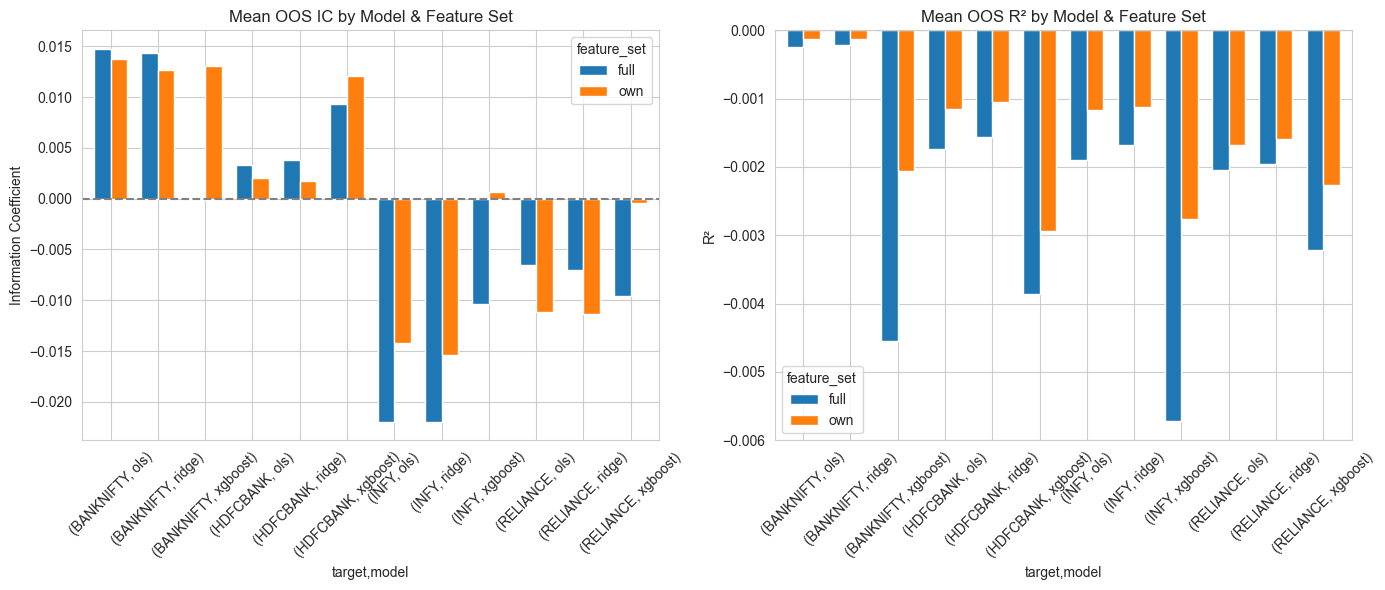

In [5]:
summary_rows = []
for (target, fs, mn), grp in results_df.groupby(['target', 'feature_set', 'model']):
    s = summarise_results(grp)
    s['target'] = target
    s['feature_set'] = fs
    s['model'] = mn
    summary_rows.append(s)

summary = pd.DataFrame(summary_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mean OOS IC
pivot_ic = summary.pivot_table(index=['target', 'model'], columns='feature_set', values='mean_ic')
pivot_ic.plot(kind='bar', ax=axes[0], width=0.7)
axes[0].set_title('Mean OOS IC by Model & Feature Set')
axes[0].set_ylabel('Information Coefficient')
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].tick_params(axis='x', rotation=45)

# Mean OOS R²
pivot_r2 = summary.pivot_table(index=['target', 'model'], columns='feature_set', values='mean_r2')
pivot_r2.plot(kind='bar', ax=axes[1], width=0.7)
axes[1].set_title('Mean OOS R² by Model & Feature Set')
axes[1].set_ylabel('R²')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.5 Multi-horizon forward return analysis

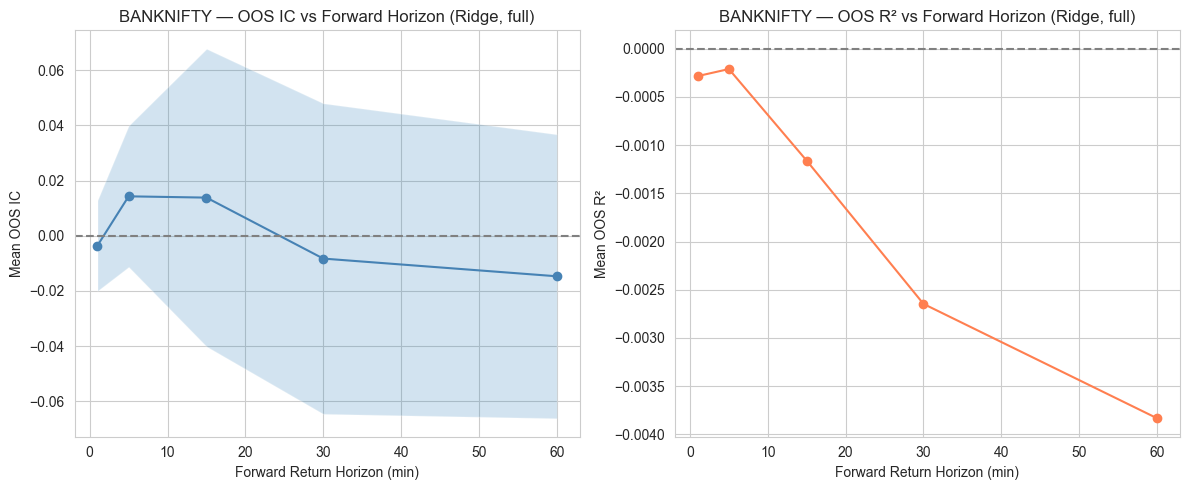

 fwd_horizon  mean_ic  ic_tstat  mean_r2
         1.0  -0.0035   -0.5697  -0.0003
         5.0   0.0143    1.4788  -0.0002
        15.0   0.0138    0.6785  -0.0012
        30.0  -0.0083   -0.3885  -0.0026
        60.0  -0.0147   -0.7548  -0.0038


In [6]:
from config import FORWARD_RETURN_HORIZONS

target = 'BANKNIFTY'
close = panel[target]['close']

horizon_results = []
for fwd_h in FORWARD_RETURN_HORIZONS:
    X, y = prepare_dataset(ofi_df, close, target, feature_set='full', fwd_horizon=fwd_h)
    res = run_walk_forward(X, y, model_name='ridge')
    s = summarise_results(res)
    s['fwd_horizon'] = fwd_h
    horizon_results.append(s)

horizon_df = pd.DataFrame(horizon_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(horizon_df['fwd_horizon'], horizon_df['mean_ic'], 'o-', color='steelblue')
axes[0].fill_between(horizon_df['fwd_horizon'],
                      horizon_df['mean_ic'] - horizon_df['std_ic'],
                      horizon_df['mean_ic'] + horizon_df['std_ic'], alpha=0.2)
axes[0].set_title(f'{target} — OOS IC vs Forward Horizon (Ridge, full)')
axes[0].set_xlabel('Forward Return Horizon (min)')
axes[0].set_ylabel('Mean OOS IC')
axes[0].axhline(0, color='gray', linestyle='--')

axes[1].plot(horizon_df['fwd_horizon'], horizon_df['mean_r2'], 'o-', color='coral')
axes[1].set_title(f'{target} — OOS R² vs Forward Horizon (Ridge, full)')
axes[1].set_xlabel('Forward Return Horizon (min)')
axes[1].set_ylabel('Mean OOS R²')
axes[1].axhline(0, color='gray', linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/figures/horizon_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(horizon_df[['fwd_horizon', 'mean_ic', 'ic_tstat', 'mean_r2']].round(4).to_string(index=False))

## 5.6 Final conclusion

**Interview-ready summary:**

> "I ran a cross-asset OFI study on NSE 1-minute data. The question was whether Nifty's order flow
> imbalance leaks predictive signal into Bank Nifty and large-cap stock returns at short horizons.
> Using walk-forward out-of-sample validation with Ridge regression:
>
> - **Own-asset OFI** provides a measurable signal at the 1–5 minute horizon (check IC and R² above)
> - **Cross-asset OFI** from Nifty adds [check delta_r2] incremental R² at the 5-minute horizon
> - The signal decays substantially by 30–60 minutes
> - Ridge and OLS perform comparably; XGBoost shows [marginal/no] improvement, consistent with
>   the literature that OFI–return relationships are primarily linear
>
> A null result (cross-asset adds nothing) is equally valid — it means own-asset OFI already
> captures the relevant microstructure information for that asset."

In [7]:
# Print the final incremental R² table for the write-up
print("\n" + "=" * 80)
print("FINAL RESULTS: Incremental R² from Cross-Asset OFI")
print("=" * 80)
incr = pd.read_csv('../outputs/tables/incremental_r2.csv')
print(incr.round(6).to_string(index=False))

print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
summ = pd.read_csv('../outputs/tables/summary_table.csv')
print(summ.round(4).to_string(index=False))


FINAL RESULTS: Incremental R² from Cross-Asset OFI
   target   model  mean_delta_r2  std_delta_r2  mean_delta_ic  n_folds  pct_positive
BANKNIFTY     ols      -0.000120      0.001374       0.000996        7     57.142857
BANKNIFTY   ridge      -0.000080      0.001107       0.001638        7     57.142857
BANKNIFTY xgboost      -0.002494      0.005586      -0.013273        7     28.571429
 HDFCBANK     ols      -0.000591      0.001707       0.001313        7     57.142857
 HDFCBANK   ridge      -0.000519      0.001584       0.002006        7     57.142857
 HDFCBANK xgboost      -0.000916      0.003272      -0.002696        7     42.857143
 RELIANCE     ols      -0.000358      0.000915       0.004672        7     28.571429
 RELIANCE   ridge      -0.000369      0.000801       0.004359        7     28.571429
 RELIANCE xgboost      -0.000950      0.003028      -0.009183        7     42.857143
     INFY     ols      -0.000732      0.000630      -0.007691        7     14.285714
     INFY   r